<a href="https://colab.research.google.com/github/adiHande/Chicago_Crime_Analysis/blob/main/Chicago_Crime_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Crime Data Analysis

This Google Colab notebook uses the `chicago_crime.csv` dataset.

Run the cells from top to bottom.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## 2. Upload and Load the Dataset

In [2]:
# Upload chicago_crime.csv from your computer when prompted.
from google.colab import files

uploaded = files.upload()

In [3]:
df = pd.read_csv("chicago_crime.csv")

df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13229983,JG447140,10/02/2023 00:01,107XX S STATE LINE RD,910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,...,10.0,52,7,1205119.0,1834444.0,2023,10/10/2023 15:42,41.700371,-87.524542,"(41.700371121, -87.524541776)"
1,13265845,JG490838,11/04/2023 00:30,106XX S STATE LINE RD,910,MOTOR VEHICLE THEFT,AUTOMOBILE,STREET,False,False,...,10.0,52,7,1205117.0,1834954.0,2023,11/12/2023 15:41,41.701771,-87.524532,"(41.701770652, -87.524531562)"
2,13035173,JG214909,04/07/2023 22:00,111XX S STATE LINE RD,498,BATTERY,"AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SE...",RESIDENCE,False,True,...,10.0,52,04B,1205114.0,1831776.0,2023,08/19/2023 03:40:26 PM,41.693050,-87.524652,"(41.693050045, -87.524651806)"
3,12938918,JG100666,01/01/2023 10:30,111XX S STATE LINE RD,560,ASSAULT,SIMPLE,RESIDENCE,False,True,...,10.0,52,08A,1205114.0,1831776.0,2023,08/19/2023 03:40:26 PM,41.693050,-87.524652,"(41.693050045, -87.524651806)"
4,13172991,JG379398,08/12/2023 04:35,111XX S STATE LINE RD,486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,True,True,...,10.0,52,08B,1205114.0,1831708.0,2023,08/19/2023 03:41:54 PM,41.692863,-87.524654,"(41.692863447, -87.524654143)"


## 3. Initial Data Exploration

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250979 entries, 0 to 250978
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    250979 non-null  int64  
 1   Case Number           250979 non-null  object 
 2   Date                  250979 non-null  object 
 3   Block                 250979 non-null  object 
 4   IUCR                  250979 non-null  object 
 5   Primary Type          250979 non-null  object 
 6   Description           250979 non-null  object 
 7   Location Description  249840 non-null  object 
 8   Arrest                250979 non-null  bool   
 9   Domestic              250979 non-null  bool   
 10  Beat                  250979 non-null  int64  
 11  District              250979 non-null  int64  
 12  Ward                  250976 non-null  float64
 13  Community Area        250979 non-null  int64  
 14  FBI Code              250979 non-null  object 
 15  

In [5]:
df.describe()

,ID,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Latitude,Longitude
count,2.509790e+05,250979.000000,250979.000000,250976.000000,250979.000000,2.509440e+05,2.509440e+05,250979.0,250944.000000,250944.000000
mean,1.309647e+07,1154.902661,11.319692,23.119310,36.284956,1.165344e+06,1.887322e+06,2023.0,41.846392,-87.668729
std,6.550225e+05,712.004601,7.116028,14.007076,21.561272,1.633514e+04,3.171172e+04,0.0,0.087206,0.059472
min,2.727900e+04,111.000000,1.000000,1.000000,1.000000,1.091242e+06,1.813897e+06,2023.0,41.644590,-87.939733
25%,1.303500e+07,533.000000,5.000000,10.000000,22.000000,1.153943e+06,1.859886e+06,2023.0,41.770805,-87.710248
50%,1.312914e+07,1032.000000,10.000000,23.000000,32.000000,1.167101e+06,1.893519e+06,2023.0,41.863469,-87.662181
75%,1.322142e+07,1732.000000,17.000000,34.000000,53.000000,1.176796e+06,1.910368e+06,2023.0,41.909895,-87.626773
max,1.331905e+07,2535.000000,31.000000,50.000000,77.000000,1.205119e+06,1.951506e+06,2023.0,42.022549,-87.524532


In [6]:
df.dtypes

,0
ID,int64
Case Number,object
Date,object
Block,object
IUCR,object
Primary Type,object
Description,object
Location Description,object
Arrest,bool
Domestic,bool


In [7]:
df.isna().sum()

,0
ID,0
Case Number,0
Date,0
Block,0
IUCR,0
Primary Type,0
Description,0
Location Description,1139
Arrest,0
Domestic,0


## 4. Handle Missing Values

In [8]:
df.dropna(inplace=True)

df.isna().sum()

,0
ID,0
Case Number,0
Date,0
Block,0
IUCR,0
Primary Type,0
Description,0
Location Description,0
Arrest,0
Domestic,0


## 5. Convert Date and Create Date/Time Features

In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date']

,Date
0,2023-10-02 00:01:00
1,2023-11-04 00:30:00
2,2023-04-07 22:00:00
3,2023-01-01 10:30:00
4,2023-08-12 04:35:00
...,...
250939,2023-03-07 05:30:00
250940,2023-10-10 20:30:00
250941,2023-11-01 09:50:00
250942,2023-01-04 10:25:00


In [10]:
df['Month'] = df['Date'].dt.month
df[['Date', 'Month']].head()

,Date,Month
0,2023-10-02 00:01:00,10
1,2023-11-04 00:30:00,11
2,2023-04-07 22:00:00,4
3,2023-01-01 10:30:00,1
4,2023-08-12 04:35:00,8


In [11]:
df['Day of Week'] = df['Date'].dt.dayofweek
df[['Date', 'Day of Week']].head()

,Date,Day of Week
0,2023-10-02 00:01:00,0
1,2023-11-04 00:30:00,5
2,2023-04-07 22:00:00,4
3,2023-01-01 10:30:00,6
4,2023-08-12 04:35:00,5


In [12]:
day_of_week_dict = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

# Map the dictionary to the 'Day of Week' column
df['Day of Week'] = df['Day of Week'].map(day_of_week_dict)

df[['Date', 'Day of Week']].head()

,Date,Day of Week
0,2023-10-02 00:01:00,Monday
1,2023-11-04 00:30:00,Saturday
2,2023-04-07 22:00:00,Friday
3,2023-01-01 10:30:00,Sunday
4,2023-08-12 04:35:00,Saturday


In [13]:
# Create Hour from Date so the hourly crime histogram works.
df['Hour'] = df['Date'].dt.hour

df[['Date', 'Hour']].head()

,Date,Hour
0,2023-10-02 00:01:00,0
1,2023-11-04 00:30:00,0
2,2023-04-07 22:00:00,22
3,2023-01-01 10:30:00,10
4,2023-08-12 04:35:00,4


## 6. Remove Unneeded Column and Check Duplicates

In [16]:
df.drop('Updated On', axis=1, inplace=True)  # remove Updated On column

KeyError: "['Updated On'] not found in axis"

In [17]:
df[df.duplicated()]

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,FBI Code,X Coordinate,Y Coordinate,Year,Latitude,Longitude,Location,Month,Day of Week,Hour


## 7. Basic Crime Statistics

In [18]:
df['District'].value_counts().head(5)  # Top 5 districts with most crimes

,count
District,
8,16215
12,15127
6,15079
4,14331
11,13727


In [19]:
df['Month'].value_counts().head(3)  # Top 3 months with most crimes

,count
Month,
8,23869
7,23731
10,22638


In [20]:
df['Block'].nunique()

28375

In [21]:
df['Block'].count()

np.int64(249802)

In [22]:
len(df)

249802

## 8. Predominant Crime Types

In [23]:
# Predominant Crime Types / Top 5 Crime Types
df['Primary Type'].value_counts().head(5)

,count
Primary Type,
THEFT,54834
BATTERY,42614
CRIMINAL DAMAGE,28960
MOTOR VEHICLE THEFT,28219
ASSAULT,21778


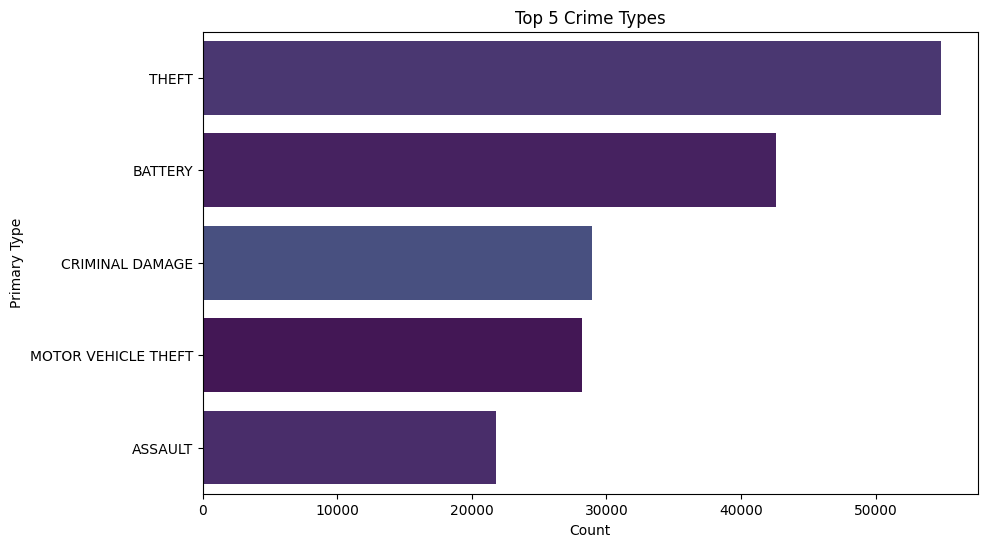

In [24]:
# Countplot to visualize the top 5 crime types
plt.figure(figsize=(10, 6))
sns.countplot(
    y='Primary Type',
    data=df,
    order=df['Primary Type'].value_counts().head(5).index,
    hue='Primary Type',
    palette='viridis',
    legend=False
)
plt.xlabel('Count')
plt.ylabel('Primary Type')
plt.title('Top 5 Crime Types')
plt.show()

## 9. Crimes by Month

In [25]:
# Count of crimes by month of the year
countByMonth = df.groupby('Month').size().reset_index(name='Crime Count')
countByMonth.head()

,Month,Crime Count
0,1,20920
1,2,18265
2,3,20543
3,4,20531
4,5,22009


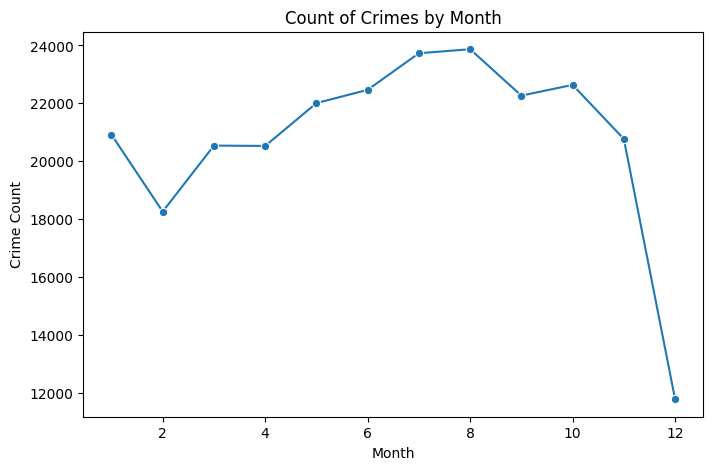

In [26]:
# Line chart for crimes by month
plt.figure(figsize=(8, 5))
sns.lineplot(x='Month', y='Crime Count', data=countByMonth, marker='o')
plt.title("Count of Crimes by Month")
plt.show()

## 10. Crimes by Day of Week

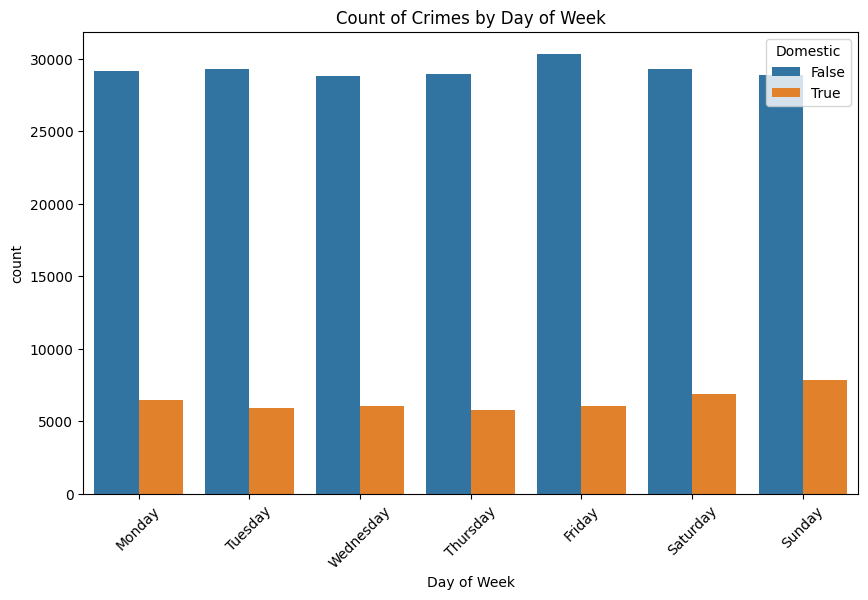

In [27]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))
sns.countplot(x='Day of Week', data=df, order=day_order, hue='Domestic')
plt.title("Count of Crimes by Day of Week")
plt.xticks(rotation=45)
plt.show()

## 11. Crimes by Hour

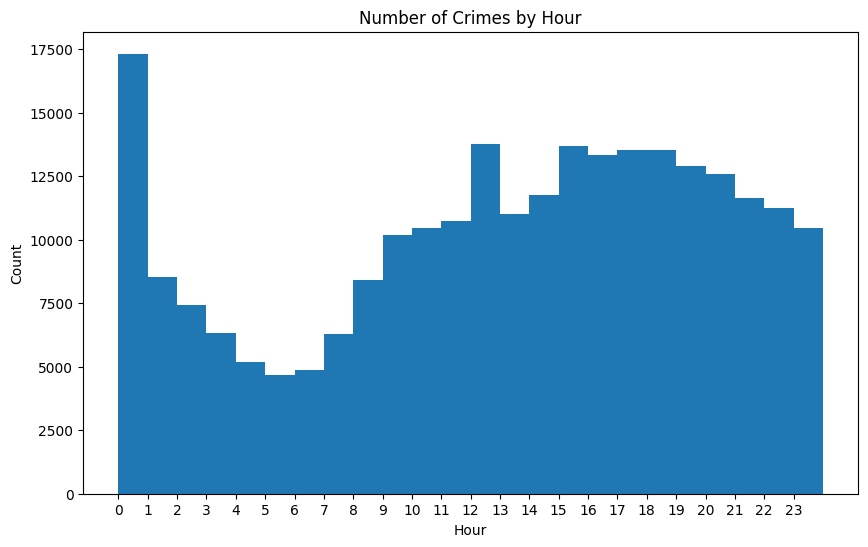

In [28]:
plt.figure(figsize=(10, 6))
plt.hist(df['Hour'], bins=24, range=(0, 24))
plt.title("Number of Crimes by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.xticks(range(0, 24))
plt.show()

## 12. Arrests vs. Non-Arrests

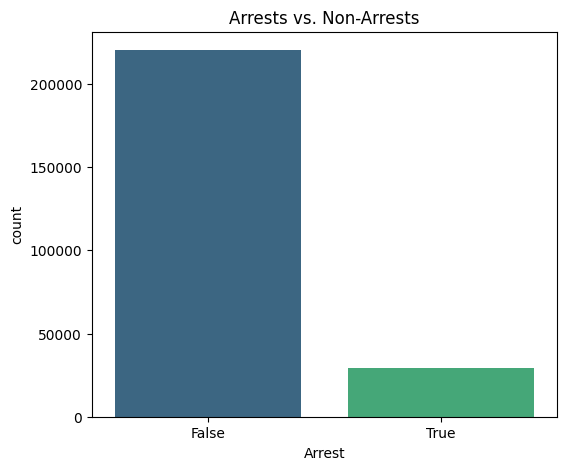

In [29]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Arrest', hue='Arrest', palette='viridis', legend=False)
plt.title("Arrests vs. Non-Arrests")
plt.show()

## 13. Domestic vs. Non-Domestic Crimes

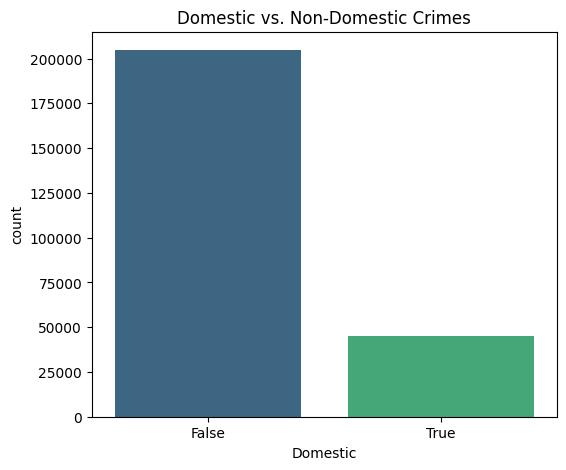

In [30]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Domestic', hue='Domestic', palette='viridis', legend=False)
plt.title("Domestic vs. Non-Domestic Crimes")
plt.show()

## 14. Number of Crimes by Crime Type

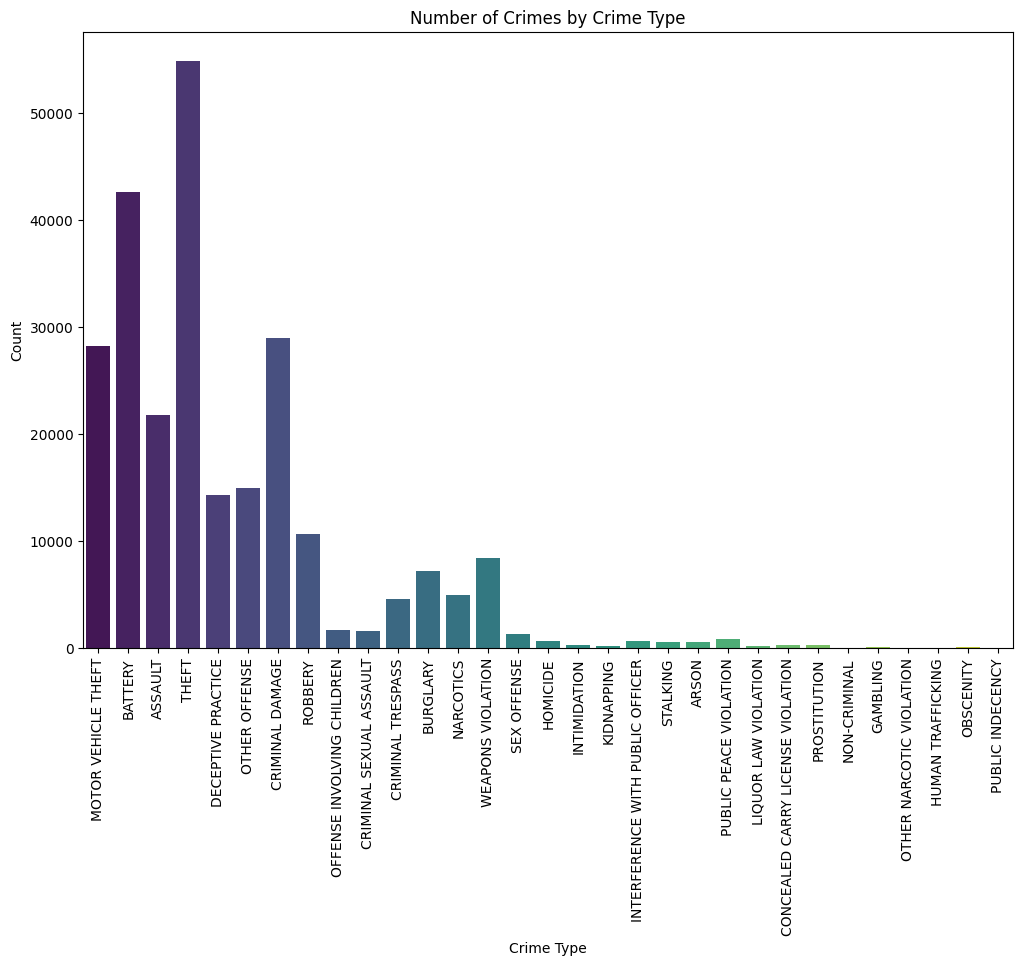

In [31]:
plt.figure(figsize=(12, 8))
sns.countplot(
    x='Primary Type',
    data=df,
    hue='Primary Type',
    palette='viridis',
    legend=False
)

plt.title('Number of Crimes by Crime Type')
plt.xlabel('Crime Type')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()